In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

Give colab access to google drive

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import numpy as np

def snr_dB(actu,pred):
    err = pred.astype(np.float32) - actu.astype(np.float32)
    err = (err - np.mean(err, axis=(0,1)))
    sigma_n = np.var(err)
    actu = (actu - np.mean(actu, axis=(0,1)))
    sigma_s = np.var(actu.astype(np.float32))
    ns = sigma_s/sigma_n
    snr = np.mean(10 * np.log10(ns))
    return snr

def MSE(actu, pred):
     return np.square(actu - pred).mean()

Load Lena Image and Plot it

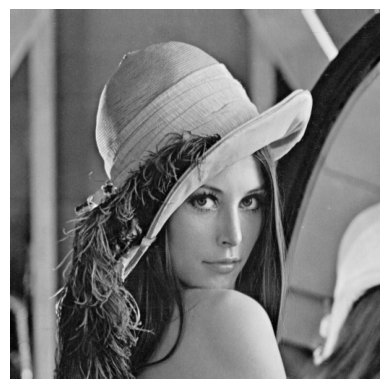

In [ ]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# image path
work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

# load image
img = sio.loadmat(work_path + 'Data/lena.mat')['lena']

# plot image
plt.imshow(img, cmap='gray')
plt.axis('off');


Add horizontal motion blur

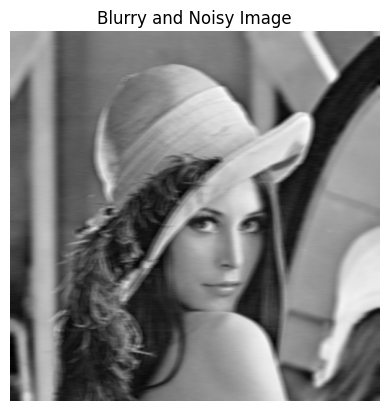

In [ ]:
import cv2

kernel_size = 10
kernel_h = np.zeros((kernel_size, kernel_size))
kernel_h[int((kernel_size - 1)/2), :] = np.ones(kernel_size)
kernel_h /= kernel_size

# Apply the horizontal kernel
img_b = cv2.filter2D(img, -1, kernel_h)

# plot image
plt.title('Blurry and Noisy Image')
plt.imshow(img_b, cmap='gray')
plt.axis('off');


Add some noise

SNR: 13.04
MSE: 99.78


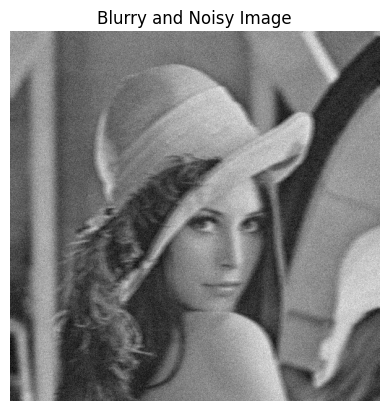

In [ ]:
import numpy as np

# add Gaussian noise
noise = np.random.normal(0, 10, img.shape)
img_n = img_b + noise

# print SNR and MSE
print('SNR:', np.round(snr_dB(img_b, img_n),2))
print('MSE:', np.round(MSE(img_b, img_n), 2))

# plot image
plt.title('Blurry and Noisy Image')
plt.imshow(img_n, cmap='gray')
plt.axis('off');


Wiener Filtering

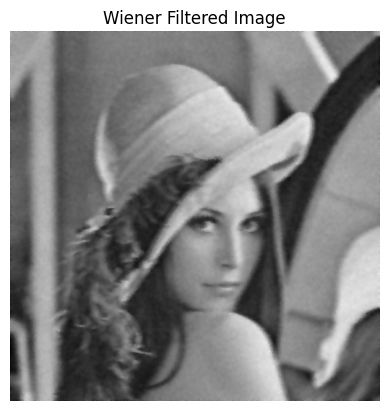

In [ ]:
from scipy.signal import wiener
filtered_img = wiener(img_n, (5, 5))

plt.title('Wiener Filtered Image')
plt.imshow(filtered_img, cmap='gray')
plt.axis('off');